<a href="https://colab.research.google.com/github/AKfrozen2/NBA_heatmap/blob/main/NBA_Shot_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# Creating NBA shot chart, need to install API to pull data
!pip install nba_api

Please enter the player's full name (e.g., Stephen Curry): 
Player '' not found. Please check the spelling and try again.
Proceeding with default player: Stephen Curry
Please enter the season (e.g., 2023-24, leave blank for 2025-26): 
Retrieving shot chart data for  (ID: 201939) for the 2025-26 season


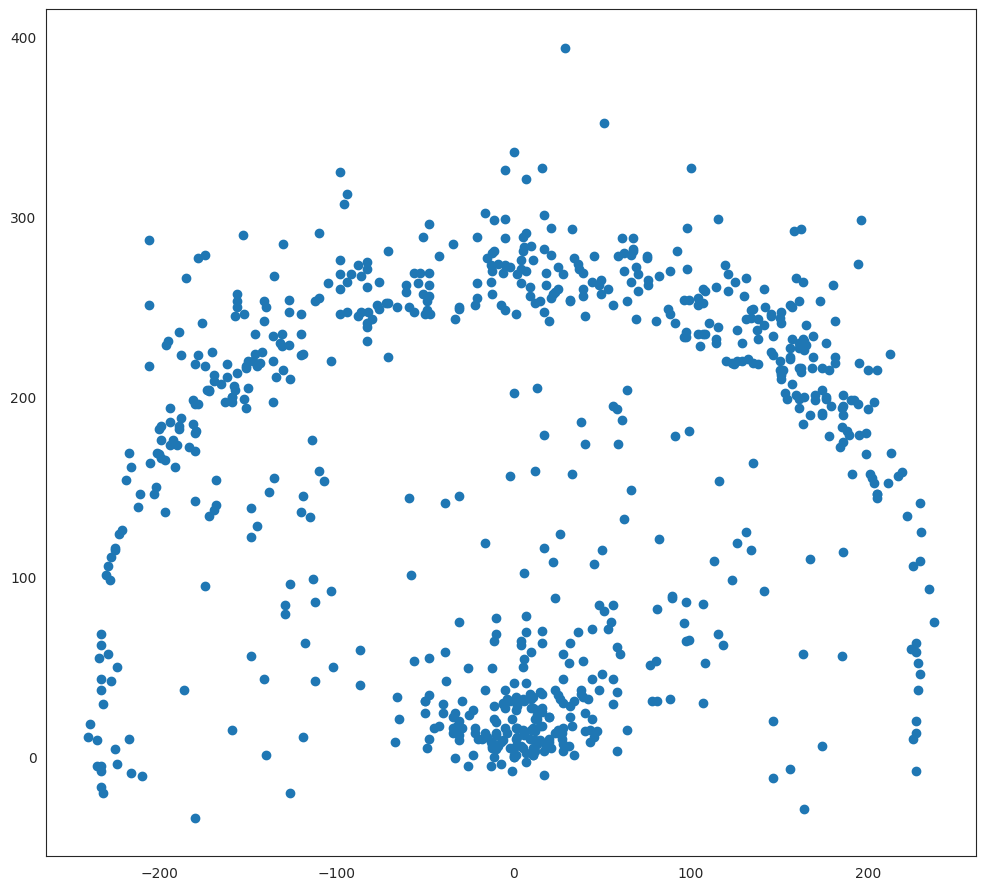

In [41]:
# Import packages
import json
import math
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players

nba_players = players.get_players()

# Prompt user for player name and find ID
chosen_player_name = input("Please enter the player's full name (e.g., Stephen Curry): ")

player_id = None
for player in nba_players:
    if player['full_name'].lower() == chosen_player_name.lower():
        player_id = player['id']
        break

if player_id is None:
    print(f"Player '{chosen_player_name}' not found. Please check the spelling and try again.")
    # Fallback to a default player if the entered name is not found
    default_player_name = "Stephen Curry" # Using a common player as default
    for player in nba_players:
        if player['full_name'] == default_player_name:
            player_id = player['id']
            print(f"Proceeding with default player: {default_player_name}")
            break
    if player_id is None:
        raise ValueError("Could not find any player, even default. Please ensure the NBA API is working and player data is available.")

# Prompt user for season
chosen_season = input("Please enter the season (e.g., 2023-24, leave blank for 2025-26): ")
if not chosen_season:
    chosen_season = "2025-26" # Default to current season if no input

print(f"Retrieving shot chart data for {chosen_player_name if chosen_player_name.lower() == default_player_name.lower() else chosen_player_name} (ID: {player_id}) for the {chosen_season} season")

response = shotchartdetail.ShotChartDetail(
    team_id = 0, # 0 for all teams, or specific team ID
    player_id = player_id, # Correctly pass the player_id
    season_nullable = chosen_season, # Use the chosen season
    season_type_all_star = "Regular Season",
    context_measure_simple = "FGA"
)

# Extract the json content
content = json.loads(response.get_json())

# Form the data set
results = content["resultSets"][0]
headers = results["headers"]
rows = results["rowSet"]
shot_data = pd.DataFrame(rows)
shot_data.columns = headers

# Create SHOT_RESULT used for heatmapping
shot_data["SHOT_RESULT"] = np.where(
    shot_data["EVENT_TYPE"] == "Made Shot", 1, 0
)

sns.set_style("white")
sns.set_color_codes()
plt.figure(figsize=(12,11))
plt.scatter(shot_data.LOC_X, shot_data.LOC_Y)
plt.show()

In [42]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

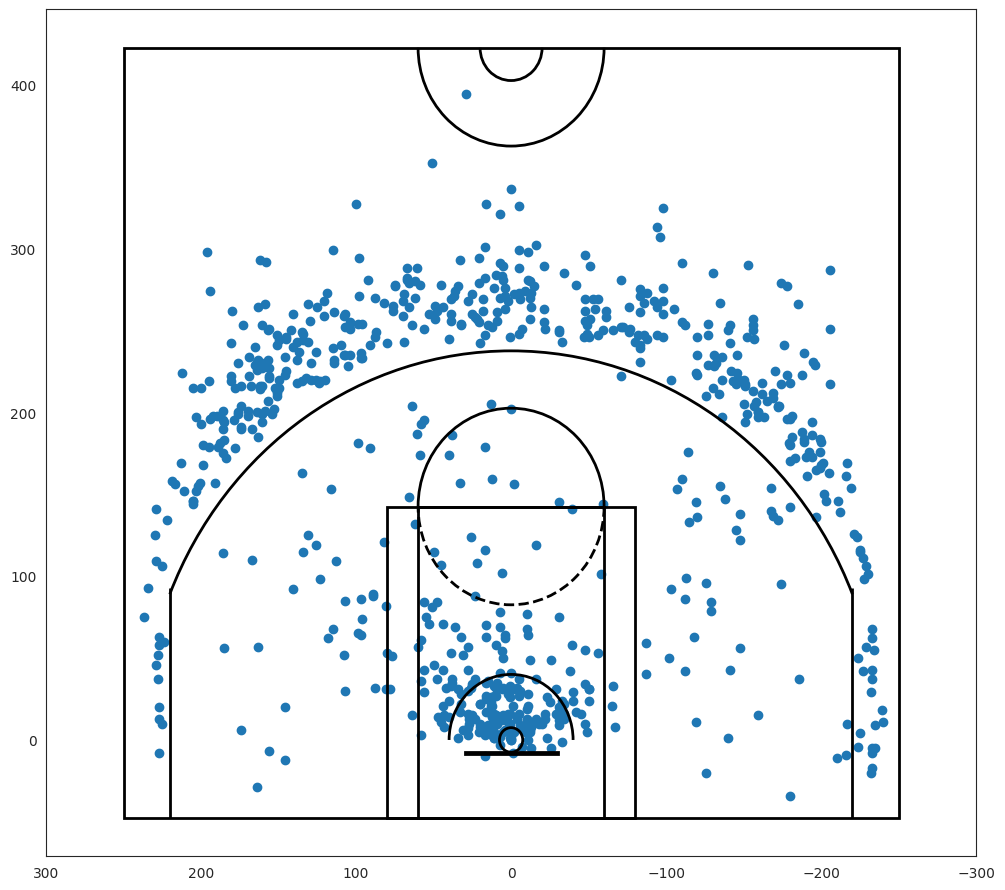

In [43]:
#shot chart
plt.figure(figsize=(12,11))
plt.scatter(shot_data.LOC_X, shot_data.LOC_Y)
draw_court(outer_lines=True)
# Descending values along the axis from left to right
plt.xlim(300,-300)
plt.show()

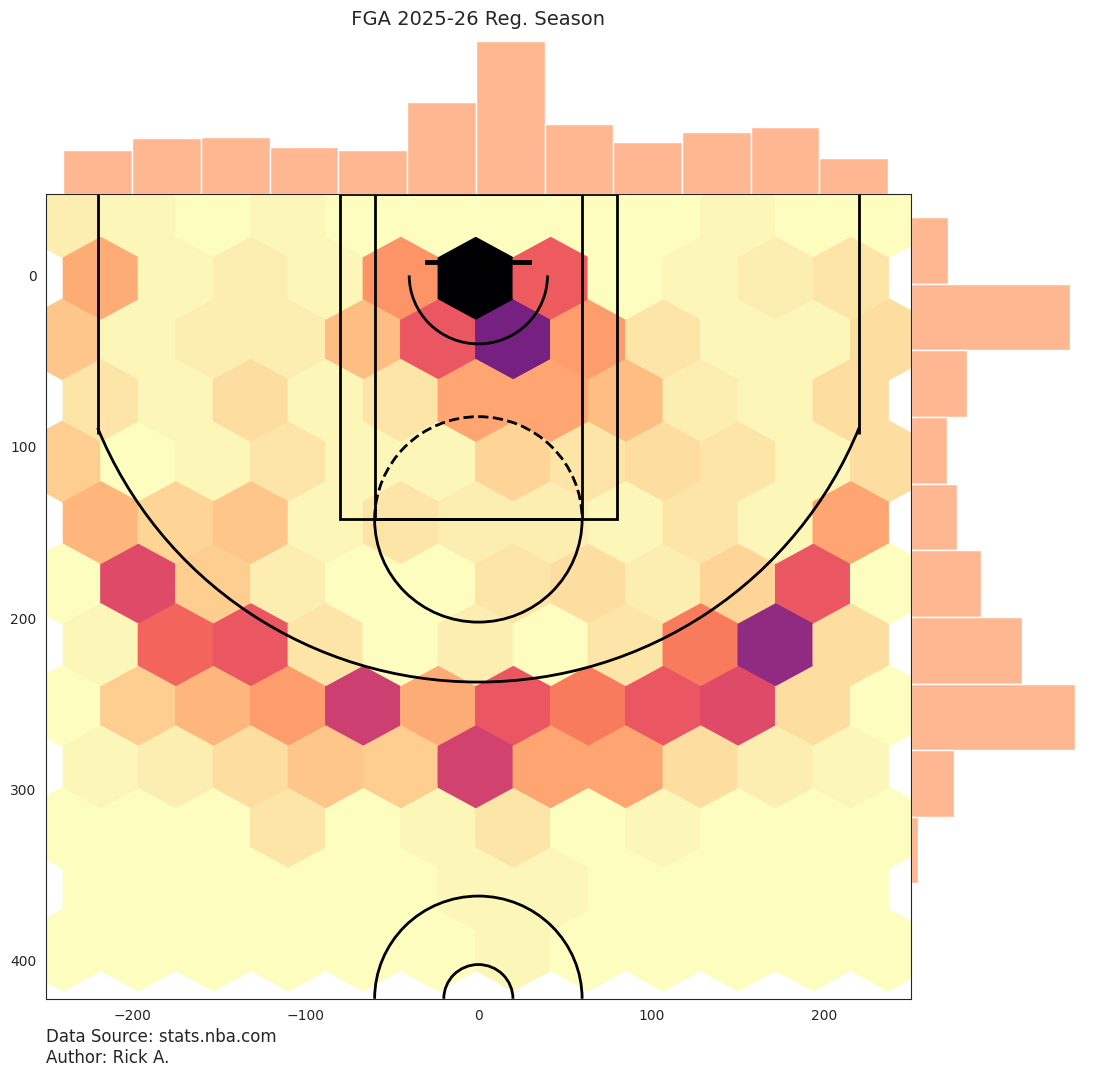

In [58]:
# create our jointplot

cmap=plt.cm.magma_r
joint_shot_chart = sns.jointplot(x=shot_data.LOC_X, y=shot_data.LOC_Y,
                                 kind='hex', space=0, color=cmap(.2), cmap=cmap)

joint_shot_chart.fig.set_size_inches(12,11)

ax = joint_shot_chart.ax_joint
draw_court(ax)

# Adjust the axis limits and orientation of the plot in order
# to plot half court, with the hoop by the top of the plot
ax.set_xlim(-250,250)
ax.set_ylim(422.5, -47.5)

# Get rid of axis labels and tick marks
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(labelbottom='off', labelleft='off')

# Add a title
ax.set_title(f'{chosen_player_name} FGA {chosen_season} Reg. Season ', y=1.2, fontsize=14)

# Add Data Source and Author
ax.text(-250,460,'Data Source: stats.nba.com'
        '\nAuthor: Rick A.', fontsize=12)

plt.show()